# OAT 2 - Baseline e Métricas de Avaliação
### Equipe Fortaleza

### Validação temporal

As features utilizam apenas valores anteriores ao instante previsto, com `shift(1)`, evitando vazamento de informações futuras. A validação é realizada com `TimeSeriesSplit`, preservando a ordem temporal dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("mecaniqa_dataset.csv", parse_dates=["Data"])
df = df.sort_values("Data").set_index("Data").asfreq("D")

# Tratamento básico para manter a série diária utilizável
df["Trocas_Oleo"] = df["Trocas_Oleo"].interpolate(method="time")
df["Manutencao_Motor"] = df["Manutencao_Motor"].interpolate(method="time")

print(df.head())
print("\nPeríodo:", df.index.min(), "até", df.index.max())

            Trocas_Oleo  Manutencao_Motor
Data                                     
2024-01-01         11.0               2.0
2024-01-02          9.0               4.0
2024-01-03         12.0               1.0
2024-01-04         15.0               8.0
2024-01-05         25.0              10.0

Período: 2024-01-01 00:00:00 até 2025-12-31 00:00:00


In [2]:
df_features = df.copy()

for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    df_features[f"{coluna}_lag_1"] = df_features[coluna].shift(1)
    df_features[f"{coluna}_lag_7"] = df_features[coluna].shift(7)
    df_features[f"{coluna}_lag_30"] = df_features[coluna].shift(30)

    df_features[f"{coluna}_media_7"] = (
        df_features[coluna]
        .shift(1)
        .rolling(window=7)
        .mean()
    )

    df_features[f"{coluna}_media_30"] = (
        df_features[coluna]
        .shift(1)
        .rolling(window=30)
        .mean()
    )

df_features.head(10)

,Trocas_Oleo,Manutencao_Motor,Trocas_Oleo_lag_1,Trocas_Oleo_lag_7,Trocas_Oleo_lag_30,Trocas_Oleo_media_7,Trocas_Oleo_media_30,Manutencao_Motor_lag_1,Manutencao_Motor_lag_7,Manutencao_Motor_lag_30,Manutencao_Motor_media_7,Manutencao_Motor_media_30
Data,,,,,,,,,,,,
2024-01-01,11.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,9.0,4.0,11.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
2024-01-03,12.0,1.0,9.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2024-01-04,15.0,8.0,12.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2024-01-05,25.0,10.0,15.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN
2024-01-06,25.0,10.0,25.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN
2024-01-07,31.0,14.0,25.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN
2024-01-08,13.0,8.0,31.0,11.0,NaN,18.285714,NaN,14.0,2.0,NaN,7.000000,NaN
2024-01-09,10.0,6.0,13.0,9.0,NaN,18.571429,NaN,8.0,4.0,NaN,7.857143,NaN


In [3]:
colunas_features = [
    "Trocas_Oleo_lag_1", "Trocas_Oleo_lag_7",
    "Trocas_Oleo_lag_30", "Trocas_Oleo_media_7",
    "Trocas_Oleo_media_30",
    "Manutencao_Motor_lag_1", "Manutencao_Motor_lag_7",
    "Manutencao_Motor_lag_30", "Manutencao_Motor_media_7",
    "Manutencao_Motor_media_30"
]

df_final = df_features.dropna(subset=colunas_features).copy()

print(df_final.head())
print("\nValores nulos:", df_final[colunas_features].isna().sum().sum())
print("Total de registros:", len(df_final))

            Trocas_Oleo  Manutencao_Motor  Trocas_Oleo_lag_1  \
Data                                                           
2024-01-31         14.0               5.0               14.0   
2024-02-01         21.0              13.0               14.0   
2024-02-02         31.0              12.0               21.0   
2024-02-03         28.0              13.0               31.0   
2024-02-04         34.0              12.0               28.0   

            Trocas_Oleo_lag_7  Trocas_Oleo_lag_30  Trocas_Oleo_media_7  \
Data                                                                     
2024-01-31               10.0                11.0            19.571429   
2024-02-01               13.0                 9.0            20.142857   
2024-02-02               30.0                12.0            21.285714   
2024-02-03               26.0                15.0            21.428571   
2024-02-04               31.0                25.0            21.714286   

            Trocas_Oleo_media_30

In [4]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for i, (treino, teste) in enumerate(tscv.split(df_final), 1):
    print(
        f"Fold {i}: "
        f"treino {df_final.index[treino[0]].date()} a {df_final.index[treino[-1]].date()} | "
        f"teste {df_final.index[teste[0]].date()} a {df_final.index[teste[-1]].date()}"
    )

Fold 1: treino 2024-01-31 a 2024-05-30 | teste 2024-05-31 a 2024-09-23
Fold 2: treino 2024-01-31 a 2024-09-23 | teste 2024-09-24 a 2025-01-17
Fold 3: treino 2024-01-31 a 2025-01-17 | teste 2025-01-18 a 2025-05-13
Fold 4: treino 2024-01-31 a 2025-05-13 | teste 2025-05-14 a 2025-09-06
Fold 5: treino 2024-01-31 a 2025-09-06 | teste 2025-09-07 a 2025-12-31


In [5]:
for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    df_final[f"{coluna}_naive"] = df_final[f"{coluna}_lag_1"]
    df_final[f"{coluna}_mm7"] = df_final[f"{coluna}_media_7"]
    df_final[f"{coluna}_mm30"] = df_final[f"{coluna}_media_30"]

df_final[
    [
        "Trocas_Oleo", "Trocas_Oleo_naive", "Trocas_Oleo_mm7", "Trocas_Oleo_mm30",
        "Manutencao_Motor", "Manutencao_Motor_naive",
        "Manutencao_Motor_mm7", "Manutencao_Motor_mm30"
    ]
].head()

,Trocas_Oleo,Trocas_Oleo_naive,Trocas_Oleo_mm7,Trocas_Oleo_mm30,Manutencao_Motor,Manutencao_Motor_naive,Manutencao_Motor_mm7,Manutencao_Motor_mm30
Data,,,,,,,,
2024-01-31,14.0,14.0,19.571429,17.900000,5.0,4.0,7.714286,6.400000
2024-02-01,21.0,14.0,20.142857,18.000000,13.0,5.0,8.142857,6.500000
2024-02-02,31.0,21.0,21.285714,18.400000,12.0,13.0,8.571429,6.800000
2024-02-03,28.0,31.0,21.428571,19.033333,13.0,12.0,8.571429,7.166667
2024-02-04,34.0,28.0,21.714286,19.466667,12.0,13.0,9.000000,7.333333


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

resultados = []

for coluna in ["Trocas_Oleo", "Manutencao_Motor"]:
    for modelo in ["naive", "mm7", "mm30"]:
        for fold, (_, teste) in enumerate(tscv.split(df_final), 1):
            real = df_final.iloc[teste][coluna]
            previsto = df_final.iloc[teste][f"{coluna}_{modelo}"]

            mae = mean_absolute_error(real, previsto)
            rmse = np.sqrt(mean_squared_error(real, previsto))

            mascara = real != 0
            mape = mean_absolute_percentage_error(
                real[mascara], previsto[mascara]
            ) * 100

            resultados.append([coluna, modelo, fold, mae, rmse, mape])

resultados_df = pd.DataFrame(
    resultados,
    columns=["Serie", "Modelo", "Fold", "MAE", "RMSE", "MAPE"]
)

resultados_df.round(2)

,Serie,Modelo,Fold,MAE,RMSE,MAPE
0,Trocas_Oleo,naive,1,6.88,9.04,49.91
1,Trocas_Oleo,naive,2,6.35,8.85,43.38
2,Trocas_Oleo,naive,3,6.61,8.69,19.08
3,Trocas_Oleo,naive,4,6.55,8.81,23.08
4,Trocas_Oleo,naive,5,6.72,9.16,27.92
5,Trocas_Oleo,mm7,1,7.47,8.18,59.07
6,Trocas_Oleo,mm7,2,7.22,7.87,49.15
7,Trocas_Oleo,mm7,3,7.30,8.16,20.83
8,Trocas_Oleo,mm7,4,7.39,8.08,26.95
9,Trocas_Oleo,mm7,5,7.48,8.24,31.32


In [8]:
resumo = (
    resultados_df
    .groupby(["Serie", "Modelo"])[["MAE", "RMSE", "MAPE"]]
    .mean()
    .round(2)
)

resumo

MAE  RMSE   MAPE
Serie            Modelo                   
Manutencao_Motor mm30    3.34  4.65  49.20
                 mm7     3.42  4.75  51.48
                 naive   3.60  5.72  46.13
Trocas_Oleo      mm30    7.34  8.18  37.52
                 mm7     7.37  8.11  37.47
                 naive   6.62  8.91  32.67

In [10]:
tabela_metricas = (
    resumo
    .reset_index()
    .rename(columns={
        "Serie": "Série",
        "Modelo": "Modelo",
        "MAE": "MAE",
        "RMSE": "RMSE",
        "MAPE": "MAPE (%)"
    })
)

tabela_metricas["Série"] = tabela_metricas["Série"].replace({
    "Manutencao_Motor": "Manutenção de Motor",
    "Trocas_Oleo": "Trocas de Óleo"
})

tabela_metricas["Modelo"] = tabela_metricas["Modelo"].replace({
    "naive": "Naive",
    "mm7": "MM7",
    "mm30": "MM30"
})

tabela_metricas

,Série,Modelo,MAE,RMSE,MAPE (%)
0,Manutenção de Motor,MM30,3.34,4.65,49.20
1,Manutenção de Motor,MM7,3.42,4.75,51.48
2,Manutenção de Motor,Naive,3.60,5.72,46.13
3,Trocas de Óleo,MM30,7.34,8.18,37.52
4,Trocas de Óleo,MM7,7.37,8.11,37.47
5,Trocas de Óleo,Naive,6.62,8.91,32.67


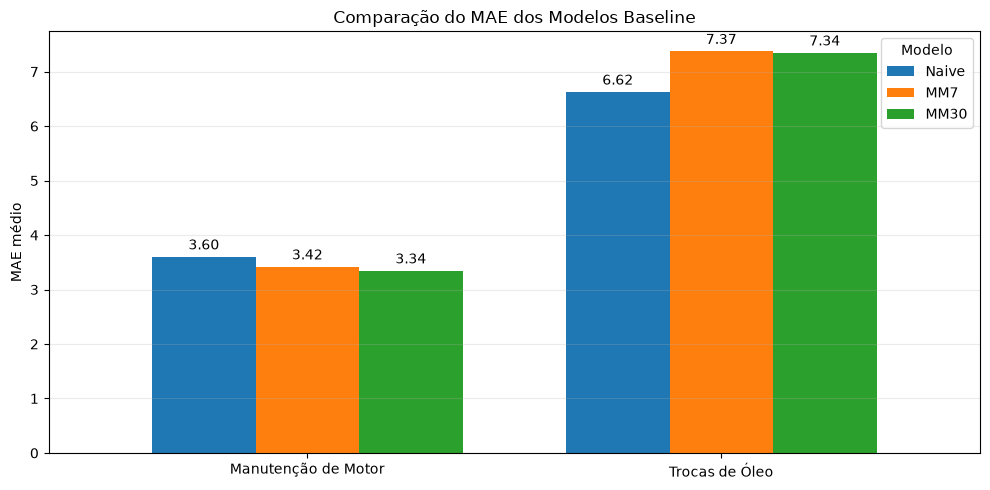

In [9]:
import matplotlib.pyplot as plt
import numpy as np

grafico_mae = (
    resultados_df
    .groupby(["Serie", "Modelo"])["MAE"]
    .mean()
    .unstack()
)


grafico_mae = grafico_mae[["naive", "mm7", "mm30"]]


grafico_mae.index = ["Manutenção de Motor", "Trocas de Óleo"]
grafico_mae.columns = ["Naive", "MM7", "MM30"]


ax = grafico_mae.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.75
)

plt.title("Comparação do MAE dos Modelos Baseline")
plt.xlabel("")
plt.ylabel("MAE médio")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y", alpha=0.25)


for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

### Análise dos resultados

Para Trocas_Oleo, o Naive apresentou menor MAE e MAPE, enquanto a MM7 obteve menor RMSE. Para Manutencao_Motor, a MM30 apresentou menor MAE e RMSE, enquanto o Naive obteve menor MAPE. Os resultados mostram que o desempenho dos baselines varia conforme a métrica considerada.